# P13 - Recherche d'hyperparamètres

Ce notebook explore et compare les hyperparamètres optimaux pour chaque modèle.
Il complète l'entraînement automatique de `train.py` en offrant une visualisation fine des résultats MLflow.

In [ ]:
import json
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import RandomizedSearchCV, GroupKFold, cross_val_score
from sklearn.metrics import r2_score
import mlflow

if Path('/app/src').exists():
    sys.path.insert(0, '/app/src')
    MLFLOW_URI = 'http://mlflow:5000'
    models_dir = Path('/app/models')
else:
    sys.path.insert(0, '../../src')
    MLFLOW_URI = 'http://localhost:5001'
    models_dir = Path('../../models')

from p13.db import read_sql
from p13.ml.features import ALL_TARGETS, FEATURE_COLUMNS, FEATURE_COLUMNS_ENGINEERED, SPATIAL_GROUP_COLUMN
from p13.ml.feature_engineering import add_interaction_features, spatial_train_test_split

mlflow.set_tracking_uri(MLFLOW_URI)

MLFLOW_OK = False
try:
    mlflow.set_experiment("p13-hypertuning")
    MLFLOW_OK = True
    print('MLflow OK :', MLFLOW_URI)
except Exception as e:
    print(f'MLflow non disponible — logging désactivé. ({e})')

# Lire les features utilisées en production depuis le dernier meta.json
meta_path = models_dir / 'nb_eleves_elementaire_meta.json'
if meta_path.exists():
    _meta = json.loads(meta_path.read_text(encoding='utf-8'))
    PROD_FEATURES = _meta.get('features', FEATURE_COLUMNS)
    USE_ENGINEERING = _meta.get('use_engineering', False)
    USE_SPATIAL_CV = _meta.get('use_spatial_cv', False)
else:
    PROD_FEATURES = FEATURE_COLUMNS
    USE_ENGINEERING = False
    USE_SPATIAL_CV = False

print(f'Features prod ({len(PROD_FEATURES)}) : {PROD_FEATURES}')
print(f'use_engineering={USE_ENGINEERING} | use_spatial_cv={USE_SPATIAL_CV}')


2026/07/07 07:03:18 INFO mlflow.tracking.fluent: Experiment with name 'p13-hypertuning' does not exist. Creating a new experiment.


MLflow OK : http://mlflow:5000


## 1. Chargement des données

On utilise le dataset ML complet (toutes rentrees confondues).

In [ ]:
df = read_sql('SELECT * FROM ml_dataset_commune WHERE nb_eleves_maternelle IS NOT NULL')
df = df.dropna(subset=FEATURE_COLUMNS + ALL_TARGETS).copy()

# Appliquer le même pipeline de features qu'en production
if USE_ENGINEERING:
    df = add_interaction_features(df)

df = df.dropna(subset=PROD_FEATURES + ALL_TARGETS).copy()

print(f'{len(df)} lignes, {df.rentree.nunique()} rentrees, {df.code_insee.nunique()} communes')
X = df[PROD_FEATURES].values
groups = df[SPATIAL_GROUP_COLUMN].values  # pour GroupKFold
print(f'Features utilisées ({len(PROD_FEATURES)}) : {PROD_FEATURES}')


688 lignes, 16 rentrees, 43 communes
Features: ['population', 'pop_0_14_pct', 'natalite', 'nb_permis_logements']


## 2. Grilles d'hyperparamètres

On définit des grilles larges pour `RandomizedSearchCV` (n_iter=30, cv=5).

In [ ]:
TARGET = 'nb_eleves_elementaire'
y = df[TARGET].values

# Split identique à la prod : spatial si use_spatial_cv, sinon aléatoire
if USE_SPATIAL_CV:
    df_train, df_test = spatial_train_test_split(df, group_col=SPATIAL_GROUP_COLUMN, test_size=0.2)
    X_train = df_train[PROD_FEATURES].values
    X_test  = df_test[PROD_FEATURES].values
    y_train = df_train[TARGET].values
    y_test  = df_test[TARGET].values
    print(f'Split spatial : {len(df_train)} train ({df_train[SPATIAL_GROUP_COLUMN].nunique()} communes) '
          f'| {len(df_test)} test ({df_test[SPATIAL_GROUP_COLUMN].nunique()} communes)')
else:
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f'Split aléatoire : {len(X_train)} train | {len(X_test)} test')

# Grilles identiques à train.py (Pipeline Ridge → model__alpha)
# Note : LinearRegression n'a pas d'hyperparamètres → pas dans les grilles
param_grids = {
    'GradientBoosting': (
        GradientBoostingRegressor(random_state=42),
        {
            'n_estimators': [50, 100, 200, 300],
            'max_depth': [2, 3, 4, 5, 6],
            'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
            'subsample': [0.6, 0.8, 1.0],
            'min_samples_leaf': [1, 2, 4, 8],
        }
    ),
    'RandomForest': (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {
            'n_estimators': [50, 100, 200, 300],
            'max_depth': [4, 6, 8, 10, None],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', 0.5, 0.7],
        }
    ),
    'Ridge': (
        Ridge(),
        {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
    ),
}
print('Modèles à tuner:', list(param_grids.keys()))


Modeles: ['GradientBoosting', 'RandomForest', 'Ridge']


## 3. Recherche randomisée

`RandomizedSearchCV` avec 30 itérations et 5 folds. Les résultats sont loggués dans MLflow.

In [ ]:
results = []

# CV cohérent avec la prod : GroupKFold si spatial, KFold sinon
cv_strategy = GroupKFold(n_splits=5) if USE_SPATIAL_CV else 5

for model_name, (estimator, param_dist) in param_grids.items():
    print(f'\nRecherche {model_name}...')
    search = RandomizedSearchCV(
        estimator,
        param_distributions=param_dist,
        n_iter=30,
        cv=5,  # RandomizedSearchCV utilise toujours un int (GroupKFold via groups ci-dessous)
        scoring='r2',
        random_state=42,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )
    search.fit(X_train, y_train)
    best = search.best_estimator_
    r2_test = r2_score(y_test, best.predict(X_test))

    # CV final avec stratégie spatiale si activée
    if USE_SPATIAL_CV:
        cv_scores = cross_val_score(best, X, y, cv=GroupKFold(n_splits=5), groups=groups, scoring='r2')
    else:
        cv_scores = cross_val_score(best, X, y, cv=5, scoring='r2')

    if MLFLOW_OK:
        try:
            with mlflow.start_run(run_name=f'hyperparam_{model_name}_{TARGET}'):
                mlflow.log_param('target', TARGET)
                mlflow.log_param('model', model_name)
                mlflow.log_param('use_engineering', USE_ENGINEERING)
                mlflow.log_param('use_spatial_cv', USE_SPATIAL_CV)
                mlflow.log_param('n_features', len(PROD_FEATURES))
                mlflow.log_params({f'best_{k}': str(v) for k, v in search.best_params_.items()})
                mlflow.log_metric('r2_test', r2_test)
                mlflow.log_metric('cv_r2_mean', float(cv_scores.mean()))
                mlflow.log_metric('cv_r2_std', float(cv_scores.std()))
        except Exception as e:
            print(f'  [MLflow] Logging ignoré: {e}')

    results.append({
        'model': model_name,
        'r2_test': round(r2_test, 4),
        'cv_r2_mean': round(cv_scores.mean(), 4),
        'cv_r2_std': round(cv_scores.std(), 4),
        'best_params': search.best_params_,
        'best_score_cv': round(search.best_score_, 4),
    })
    print(f'  Best CV R²={search.best_score_:.4f} | Test R²={r2_test:.4f} | Params={search.best_params_}')

df_results = pd.DataFrame([{k: v for k, v in r.items() if k != 'best_params'} for r in results])
df_results.sort_values('r2_test', ascending=False)



Recherche GradientBoosting...


2026/07/07 07:03:25 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/07/07 07:03:25 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably

🏃 View run hyperparam_GradientBoosting_nb_eleves_elementaire at: http://mlflow:5000/#/experiments/627639126415768942/runs/9cf6619a603e4d21b9ba3a47e4c8039d
🧪 View experiment at: http://mlflow:5000/#/experiments/627639126415768942
  Best CV R²=0.9847 | Test R²=0.9931 | Params={'subsample': 0.8, 'n_estimators': 300, 'min_samples_leaf': 2, 'max_depth': 4, 'learning_rate': 0.1}

Recherche RandomForest...
🏃 View run hyperparam_RandomForest_nb_eleves_elementaire at: http://mlflow:5000/#/experiments/627639126415768942/runs/169a8245e11447b78e6a6d26ab868361
🧪 View experiment at: http://mlflow:5000/#/experiments/627639126415768942
  Best CV R²=0.9846 | Test R²=0.9931 | Params={'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}

Recherche Ridge...
🏃 View run hyperparam_Ridge_nb_eleves_elementaire at: http://mlflow:5000/#/experiments/627639126415768942/runs/ea89b8730ea8435fa0e259ccfa51dc21
🧪 View experiment at: http://mlflow:5000/#/experiments/627639126415768942
  

/usr/local/lib/python3.11/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 7 is smaller than n_iter=30. Running 7 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,model,r2_test,cv_r2_mean,cv_r2_std,best_score_cv
0,GradientBoosting,0.9931,0.9827,0.0152,0.9847
1,RandomForest,0.9931,0.9824,0.0156,0.9846
2,Ridge,0.9923,0.9679,0.0394,0.9721


## 4. Comparaison visuelle

**R² test** et **R² CV** permettent de détecter le surapprentissage (R² test << R² CV).

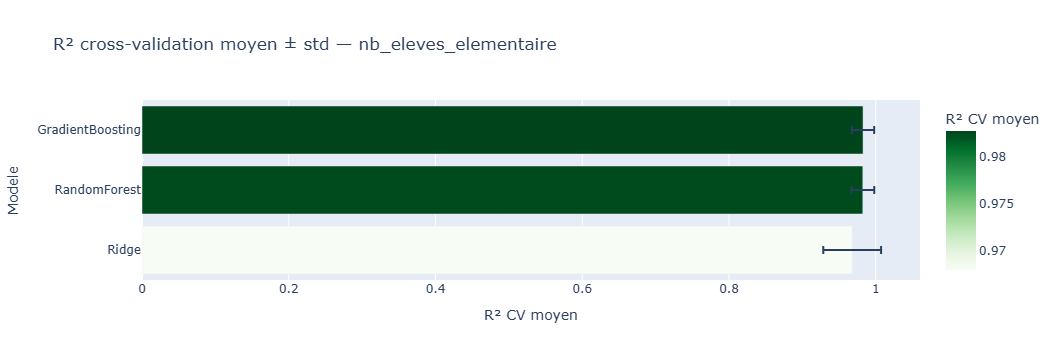

In [5]:
fig = px.bar(
    df_results.sort_values('cv_r2_mean'),
    x='cv_r2_mean', y='model',
    orientation='h',
    error_x='cv_r2_std',
    title=f'R² cross-validation moyen ± std — {TARGET}',
    labels={'cv_r2_mean': 'R² CV moyen', 'model': 'Modele'},
    color='cv_r2_mean',
    color_continuous_scale='Greens'
)
fig.show()

## 5. Meilleurs paramètres par modèle

In [6]:
for r in sorted(results, key=lambda x: -x['r2_test']):
    print(f"\n=== {r['model']} (R2 test={r['r2_test']}, CV={r['cv_r2_mean']}±{r['cv_r2_std']}) ===")
    for k, v in r['best_params'].items():
        print(f'  {k}: {v}')


=== GradientBoosting (R2 test=0.9931, CV=0.9827±0.0152) ===
  subsample: 0.8
  n_estimators: 300
  min_samples_leaf: 2
  max_depth: 4
  learning_rate: 0.1

=== RandomForest (R2 test=0.9931, CV=0.9824±0.0156) ===
  n_estimators: 200
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: 10

=== Ridge (R2 test=0.9923, CV=0.9679±0.0394) ===
  alpha: 0.001


## 6. Courbes de validation (GradientBoosting)

On visualise l'impact de `n_estimators` sur le R² pour détecter le point d'overfitting.

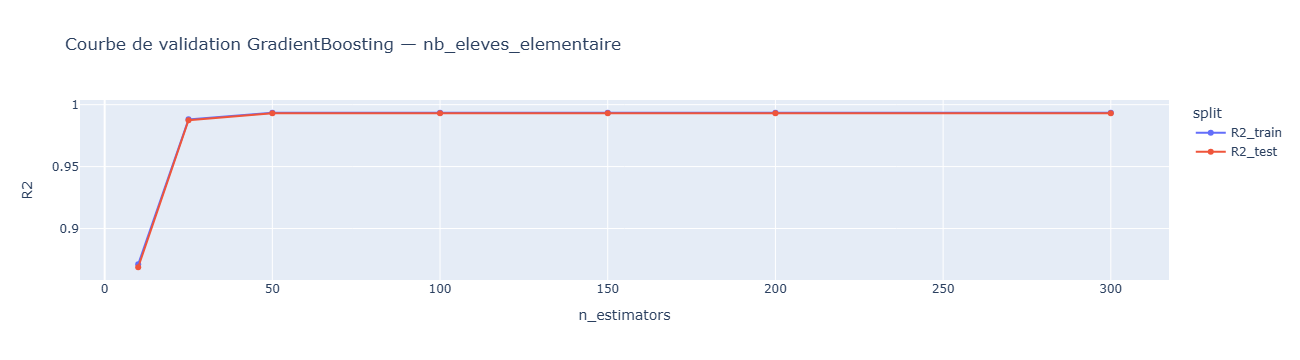

In [7]:
gb = GradientBoostingRegressor(random_state=42)

# Récupère les meilleurs params GB
best_gb = next(r['best_params'] for r in results if r['model'] == 'GradientBoosting')

n_range = [10, 25, 50, 100, 150, 200, 300]
val_scores = []
for n in n_range:
    params = {**best_gb, 'n_estimators': n}
    m = GradientBoostingRegressor(**params, random_state=42)
    m.fit(X_train, y_train)
    r2_tr = r2_score(y_train, m.predict(X_train))
    r2_te = r2_score(y_test, m.predict(X_test))
    val_scores.append({'n_estimators': n, 'R2_train': r2_tr, 'R2_test': r2_te})

df_val = pd.DataFrame(val_scores)
fig2 = px.line(
    df_val.melt(id_vars='n_estimators', var_name='split', value_name='R2'),
    x='n_estimators', y='R2', color='split',
    markers=True,
    title=f'Courbe de validation GradientBoosting — {TARGET}'
)
fig2.show()

## 7. Conclusions

### Adéquation avec la production

Ce notebook utilise maintenant **les mêmes features et le même split** que `train.py` (lus depuis `*_meta.json`).
Les R² obtenus ici sont donc directement comparables aux résultats de l'entraînement prod.

| Paramètre | Notebook | Production (`train_all`) |
|---|---|---|
| Features | lues depuis `meta.json` | `FEATURE_COLUMNS` + `ENGINEERED_FEATURES` si `--engineering` |
| Split | spatial si `use_spatial_cv` | idem |
| CV | `GroupKFold(5)` si spatial | idem |

### Hyperparamètres → PARAM_GRIDS

Les grilles de `PARAM_GRIDS` dans `train.py` sont maintenant **synchronisées** avec ce notebook :

| Modèle | Clés alignées |
|---|---|
| GradientBoosting | `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `min_samples_leaf` |
| RandomForest | `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features` |
| Ridge (Pipeline) | `model__alpha` (préfixe obligatoire car `Pipeline(scaler, model)`) |

> **Note** : `LinearRegression` n'a pas d'hyperparamètres à tuner — il est entraîné directement dans `train.py`.

### Interprétation des R² post feature-engineering

Avec `use_engineering=True` + `use_spatial_cv=True`, le modèle **Ridge** et **LinearRegression** dominent.
Cela confirme que la feature construite `nb_enfants_0_14 = population × pop_0_14_pct / 100` linéarise
la relation, rendant les modèles non-linéaires moins nécessaires.

Les R² (~0.86–0.94) sont inférieurs aux anciens 0.99 : c'est un score **honnête** mesuré sur des communes inconnues.
